In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
 

### config experiment

In [2]:
import os

working_dir = os.getcwd()
print(working_dir)

parts = working_dir.split("/")

#if parts[-1] == "pipeline":
if parts[-1].startswith("pipeline"): ### BUG SOLVED MAY 2025
    pipeline = working_dir
else:
    pipeline ="/".join(parts[:-1])
print(pipeline)

/home/ematos/phd/pipeline_city/GRAFICOS
/home/ematos/phd/pipeline_city


In [3]:
import sys 
base = pipeline
sys.path.append(base)

from config.configsite import *

#print(f"filesdir = {filesdir}") # new AT april 2025
print(f"pipeline = {pipeline}") # new AT april 2025

pipeline = /home/ematos/phd/pipeline_city/


# ler dados (BIO)

In [4]:
results_flair_dir=pipeline+"PROCESS_TEST_SET_WITH_NER_FLAIR/"+resultsdir

In [5]:

df = pd.read_csv(results_flair_dir+"output_bio.csv",sep="\t" ) 

df

,word,tag
0,é,O
1,a,O
2,capital,O
3,do,O
4,Peru,O
...,...,...
17577,do,O
17578,que,O
17579,o,O
17580,inglês,O


In [6]:
df2 = df[df.tag != 'O']
df2.head()

,word,tag
15,cidade,ENTIDADE_TERRITORIAL_ARTIFICIAL
79,Lima,ENTIDADE_TERRITORIAL_ARTIFICIAL
85,cidade,ENTIDADE_TERRITORIAL_ARTIFICIAL
102,cidade,ENTIDADE_TERRITORIAL_ARTIFICIAL
140,cidade,ENTIDADE_TERRITORIAL_ARTIFICIAL


In [7]:
contagens = df2.value_counts("tag")
c = pd.DataFrame(contagens).reset_index()
c

,tag,count
0,ENTIDADE_TERRITORIAL_ARTIFICIAL,147
1,CIDADE_DOS_ESTADOS_UNIDOS,39
2,MUNICÍPIO_DE_PORTUGAL,26
3,CIDADE,12
4,CIDADE_GRANDE,7
5,FREGUESIA_DE_PORTUGAL,7
6,PAÍS,3


In [8]:
#!pip install seaborn

<Axes: xlabel='count', ylabel='tag'>

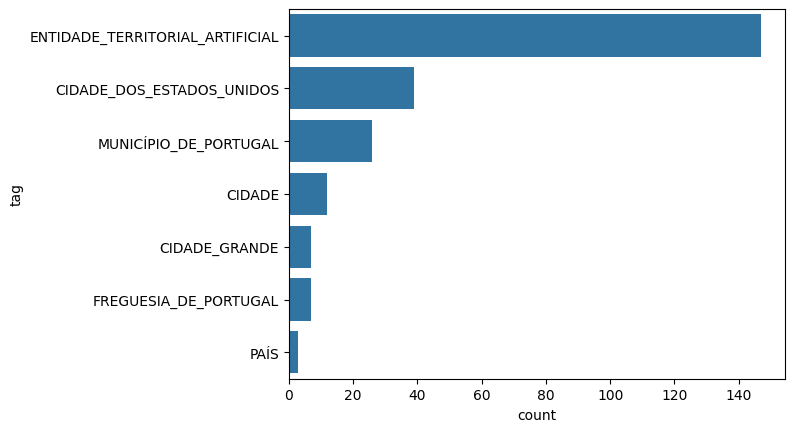

In [9]:
import seaborn as sns
sns.barplot(data  = c,
            y='tag',
            x='count'
           )

In [10]:
aux = df2[df2.tag == "PAÍS"]["word"].unique()
print(aux)

['Rico' 'Cana' 'Angola']


In [11]:
def counts(df2, ent):
    aux = df2[df2.tag == ent]["word"].unique()
    #print(aux)

    return (list(aux))

In [12]:
r =counts (df2, "PAÍS")
print(r)

['Rico', 'Cana', 'Angola']


In [13]:
r =counts (df2, "CIDADE")
print(r)

['Munster', 'Kaunas', 'Vilnius', 'Londres', 'Lima', 'Praga', 'Rimini', 'Rússia', 'Budapeste']


In [14]:
entidades = df2.tag.unique()
entidades

array(['ENTIDADE_TERRITORIAL_ARTIFICIAL', 'MUNICÍPIO_DE_PORTUGAL',
       'CIDADE', 'FREGUESIA_DE_PORTUGAL', 'CIDADE_GRANDE',
       'CIDADE_DOS_ESTADOS_UNIDOS', 'PAÍS'], dtype=object)

In [15]:
num_difs =[]
ents = []
for e in entidades:
    r =counts (df2, e)
    r2 = len(r)
    num_difs.append(r2)
    ents.append(e)

print(num_difs)
print(ents)    

[20, 14, 9, 2, 2, 23, 3]
['ENTIDADE_TERRITORIAL_ARTIFICIAL', 'MUNICÍPIO_DE_PORTUGAL', 'CIDADE', 'FREGUESIA_DE_PORTUGAL', 'CIDADE_GRANDE', 'CIDADE_DOS_ESTADOS_UNIDOS', 'PAÍS']


In [16]:
c2 = pd.DataFrame({'entity':ents, 'num different words':num_difs})

## gráfico com num de differente words per entity

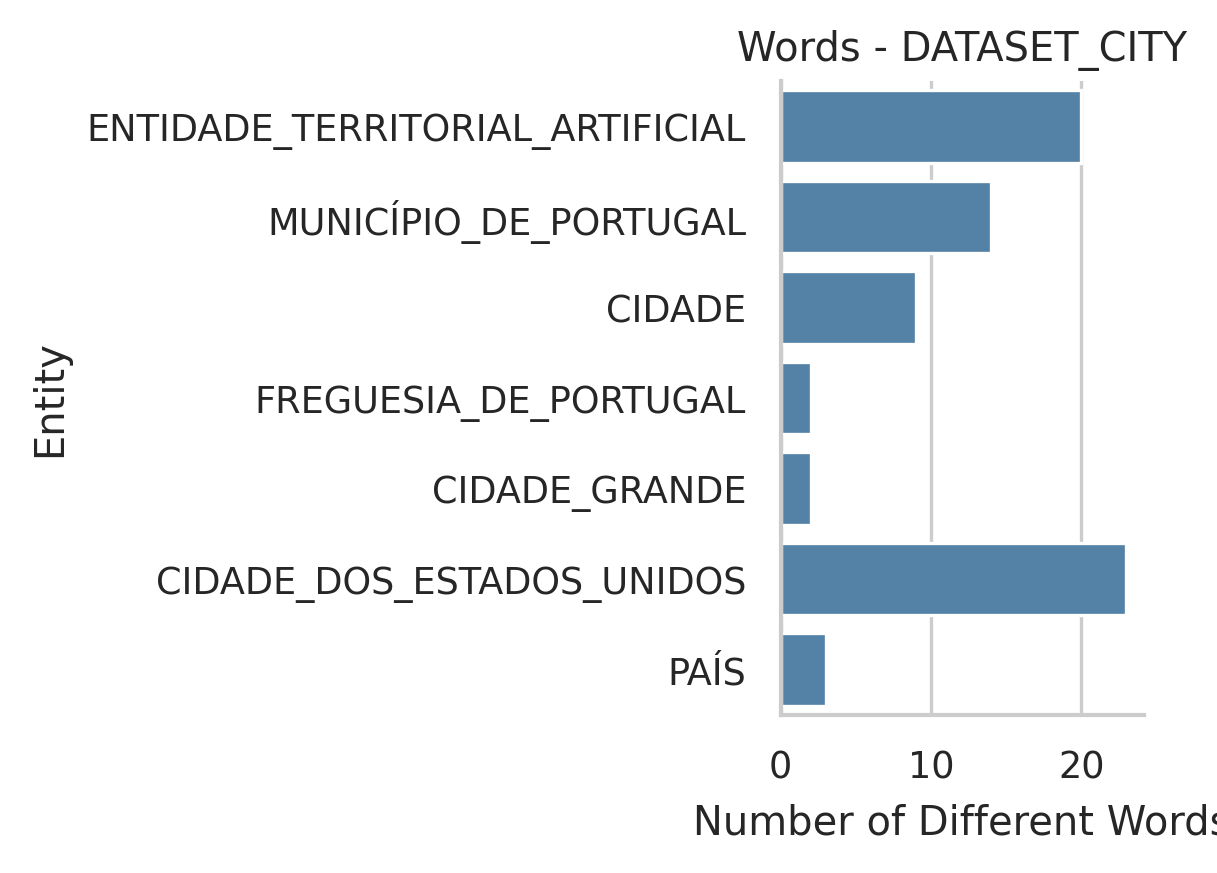

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# Configuração compacta
# ============================
plt.rcParams.update({
    "font.size": 7,             # fonte geral menor
    "axes.titlesize": 8,        # título
    "axes.labelsize": 6,        # labels eixos
    "xtick.labelsize": 5,       # ticks X
    "ytick.labelsize": 5,       # ticks Y
    "font.family": "DejaVu Sans",  # fonte legível e disponível
    "figure.dpi": 300
})

sns.set_theme(style="whitegrid", context="paper")  # paper = mais compacto

# ============================
# Criação do gráfico
# ============================
plt.figure(figsize=(4, 3))  # tamanho reduzido
ax = sns.barplot(
    data=c2,
    y='entity',
    x='num different words',
    color="steelblue"  # cor única, sem warning
)

# Título e labels
ax.set_title(f"Words - {dataset}", pad=5)
ax.set_xlabel("Number of Different Words")
ax.set_ylabel("Entity")

# Remove bordas extras
sns.despine()

# Ajusta layout
plt.tight_layout()

# Salva com alta qualidade
plt.savefig(f"words_{dataset}.png", dpi=300, bbox_inches='tight')

# Mostra
plt.show()


In [ ]:
r =counts (df2, "CIDADE_GRANDE")
print(r)

In [ ]:
r =counts (df2, "FILME")
print(r)